# PaySim Fraud Detection – Baseline Models
### DATA 245 · Spring 2026
#### Models: Logistic Regression · Naive Bayes · k-NN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, brier_score_loss
)
from imblearn.over_sampling import SMOTE
from collections import Counter

plt.rcParams['figure.dpi'] = 110
FRAUD_COLOR  = '#E63946'
LEGIT_COLOR  = '#457B9D'
COLORS = ['#2C3E50','#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261']

df = pd.read_csv('PS_20174392719_1491204439457_log.csv')  
print(f'Loaded: {df.shape}')

Loaded: (6362620, 11)


## Preprocessing (inline – run this before models)

In [2]:
# Drop leakage columns
df = df.drop(columns=['nameOrig','nameDest','isFlaggedFraud'])

# Feature engineering
df['log_amount']        = np.log1p(df['amount'])
df['balance_diff_orig'] = df['oldbalanceOrg']  - df['newbalanceOrig']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']
df['errorBalanceOrig']  = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest']  = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
df['zero_orig_after']   = (df['newbalanceOrig'] == 0).astype(int)
df['zero_dest_before']  = (df['oldbalanceDest'] == 0).astype(int)
df['is_transfer']       = (df['type'] == 'TRANSFER').astype(int)
df['is_cashout']        = (df['type'] == 'CASH_OUT').astype(int)
type_dummies = pd.get_dummies(df['type'], prefix='type', drop_first=False)
df = pd.concat([df, type_dummies], axis=1).drop(columns=['type','amount'])

FEATURES = [c for c in df.columns if c != 'isFraud']
X = df[FEATURES]
y = df['isFraud']

# 70/15/15 split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15/0.85, random_state=42, stratify=y_temp)

# Scale
scaler    = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES)
X_val_s   = pd.DataFrame(scaler.transform(X_val),       columns=FEATURES)
X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURES)

# SMOTE on train only
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_s, y_train)

print(f'Train: {X_train_s.shape}  Val: {X_val_s.shape}  Test: {X_test_s.shape}')
print(f'SMOTE train: {X_train_smote.shape}')

Train: (4453833, 19)  Val: (954394, 19)  Test: (954393, 19)
SMOTE train: (8896168, 19)


## Helper: Evaluation Function

In [3]:
def evaluate(name, model, X_val, y_val, threshold=0.5):
    """Compute all metrics for a fitted model on validation set."""
    proba = model.predict_proba(X_val)[:, 1]
    preds = (proba >= threshold).astype(int)

    # Business cost: FN=$500, FP=$10
    cm    = confusion_matrix(y_val, preds)
    tn, fp, fn, tp = cm.ravel()
    cost  = fn * 500 + fp * 10

    return {
        'Model'      : name,
        'Accuracy'   : accuracy_score(y_val, preds),
        'Precision'  : precision_score(y_val, preds, zero_division=0),
        'Recall'     : recall_score(y_val, preds, zero_division=0),
        'F1'         : f1_score(y_val, preds, zero_division=0),
        'ROC-AUC'    : roc_auc_score(y_val, proba),
        'PR-AUC'     : average_precision_score(y_val, proba),
        'Brier'      : brier_score_loss(y_val, proba),
        'Cost ($)'   : cost,
        'TP' : tp, 'FP': fp, 'TN': tn, 'FN': fn,
        '_proba'     : proba,
        '_preds'     : preds,
    }

all_results = []
print('Evaluation function ready.')

Evaluation function ready.


## Model 1: Logistic Regression

Training Logistic Regression variants...
  class_weight – F1: 0.0735  ROC-AUC: 0.9961  PR-AUC: 0.5893
  SMOTE          – F1: 0.0784  ROC-AUC: 0.9966  PR-AUC: 0.6096


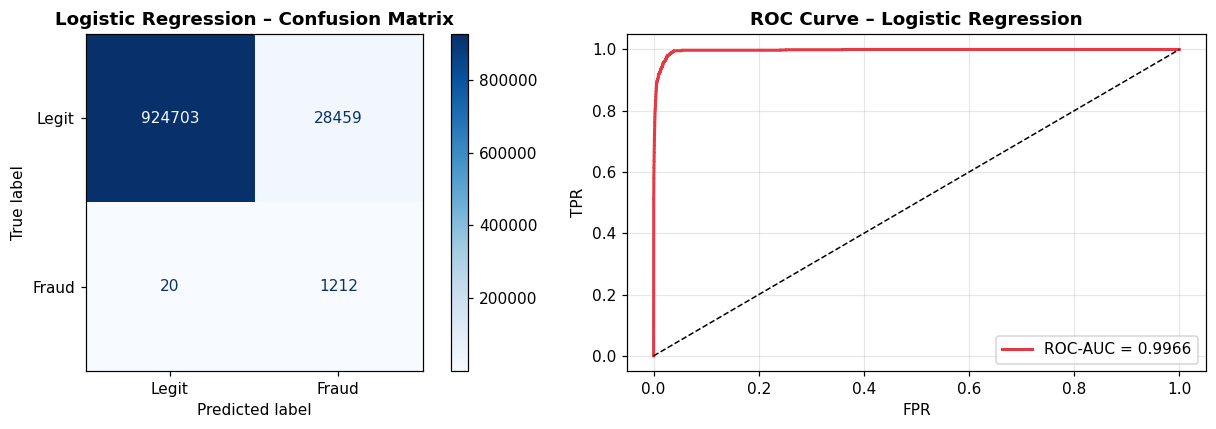

In [4]:
print('Training Logistic Regression variants...')

# Variant A: class_weight balanced
lr_cw = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)
lr_cw.fit(X_train_s, y_train)
res_lr_cw = evaluate('LR (class_weight)', lr_cw, X_val_s, y_val)
all_results.append(res_lr_cw)
print(f"  class_weight – F1: {res_lr_cw['F1']:.4f}  ROC-AUC: {res_lr_cw['ROC-AUC']:.4f}  PR-AUC: {res_lr_cw['PR-AUC']:.4f}")

# Variant B: SMOTE
lr_sm = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_sm.fit(X_train_smote, y_train_smote)
res_lr_sm = evaluate('LR (SMOTE)', lr_sm, X_val_s, y_val)
all_results.append(res_lr_sm)
print(f"  SMOTE          – F1: {res_lr_sm['F1']:.4f}  ROC-AUC: {res_lr_sm['ROC-AUC']:.4f}  PR-AUC: {res_lr_sm['PR-AUC']:.4f}")

# Confusion matrix for best LR
best_lr = lr_cw if res_lr_cw['F1'] >= res_lr_sm['F1'] else lr_sm
best_lr_res = res_lr_cw if res_lr_cw['F1'] >= res_lr_sm['F1'] else res_lr_sm

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_val, best_lr_res['_preds'],
    display_labels=['Legit','Fraud'], cmap='Blues', ax=axes[0])
axes[0].set_title(f'Logistic Regression – Confusion Matrix', fontweight='bold')

proba = best_lr_res['_proba']
fpr, tpr, _ = roc_curve(y_val, proba)
axes[1].plot(fpr, tpr, color=FRAUD_COLOR, lw=2,
             label=f"ROC-AUC = {best_lr_res['ROC-AUC']:.4f}")
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve – Logistic Regression', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Model 2: Gaussian Naive Bayes

Training Gaussian Naive Bayes variants...
  Imbalanced – F1: 0.0065  ROC-AUC: 0.9630  PR-AUC: 0.1305
  SMOTE      – F1: 0.0066  ROC-AUC: 0.9662  PR-AUC: 0.1985


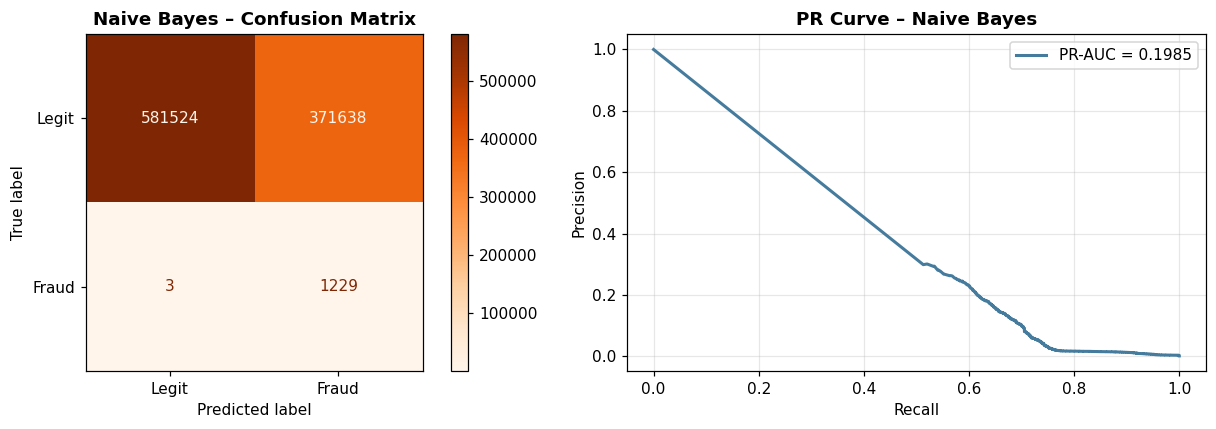

In [6]:
print('Training Gaussian Naive Bayes variants...')

# Variant A: original imbalanced training data
gnb = GaussianNB()
gnb.fit(X_train_s, y_train)
res_gnb = evaluate('GNB (imbalanced)', gnb, X_val_s, y_val)
all_results.append(res_gnb)
print(f"  Imbalanced – F1: {res_gnb['F1']:.4f}  ROC-AUC: {res_gnb['ROC-AUC']:.4f}  PR-AUC: {res_gnb['PR-AUC']:.4f}")

# Variant B: SMOTE
gnb_sm = GaussianNB()
gnb_sm.fit(X_train_smote, y_train_smote)
res_gnb_sm = evaluate('GNB (SMOTE)', gnb_sm, X_val_s, y_val)
all_results.append(res_gnb_sm)
print(f"  SMOTE      – F1: {res_gnb_sm['F1']:.4f}  ROC-AUC: {res_gnb_sm['ROC-AUC']:.4f}  PR-AUC: {res_gnb_sm['PR-AUC']:.4f}")

best_gnb_res = res_gnb if res_gnb['F1'] >= res_gnb_sm['F1'] else res_gnb_sm

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_val, best_gnb_res['_preds'],
    display_labels=['Legit','Fraud'], cmap='Oranges', ax=axes[0])
axes[0].set_title('Naive Bayes – Confusion Matrix', fontweight='bold')

prec, rec, _ = precision_recall_curve(y_val, best_gnb_res['_proba'])
axes[1].plot(rec, prec, color=LEGIT_COLOR, lw=2,
             label=f"PR-AUC = {best_gnb_res['PR-AUC']:.4f}")
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curve – Naive Bayes', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Model 3: k-Nearest Neighbors (k=5)

In [5]:
print('Training k-NN (k=5) — this may take a few minutes on large data...')

# Sub-sample for kNN if dataset is very large (>500k rows)
MAX_KNN = 200_000
if len(X_train_s) > MAX_KNN:
    idx = np.random.RandomState(42).choice(len(X_train_s), MAX_KNN, replace=False)
    X_knn_tr = X_train_s.iloc[idx]
    y_knn_tr = y_train.iloc[idx]
    print(f'  Subsampled to {MAX_KNN:,} rows for kNN efficiency')
else:
    X_knn_tr, y_knn_tr = X_train_s, y_train

knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_knn_tr, y_knn_tr)
res_knn = evaluate('kNN (k=5)', knn, X_val_s, y_val)
all_results.append(res_knn)
print(f"  F1: {res_knn['F1']:.4f}  ROC-AUC: {res_knn['ROC-AUC']:.4f}  PR-AUC: {res_knn['PR-AUC']:.4f}")

# SMOTE version
if len(X_train_smote) > MAX_KNN:
    idx2 = np.random.RandomState(42).choice(len(X_train_smote), MAX_KNN, replace=False)
    X_knn_sm = X_train_smote[idx2]
    y_knn_sm = y_train_smote[idx2]
else:
    X_knn_sm, y_knn_sm = X_train_smote, y_train_smote

knn_sm = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_sm.fit(X_knn_sm, y_knn_sm)
res_knn_sm = evaluate('kNN SMOTE (k=5)', knn_sm, X_val_s, y_val)
all_results.append(res_knn_sm)
print(f"  SMOTE F1: {res_knn_sm['F1']:.4f}  ROC-AUC: {res_knn_sm['ROC-AUC']:.4f}  PR-AUC: {res_knn_sm['PR-AUC']:.4f}")

best_knn_res = res_knn if res_knn['F1'] >= res_knn_sm['F1'] else res_knn_sm

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_val, best_knn_res['_preds'],
    display_labels=['Legit','Fraud'], cmap='Greens', ax=axes[0])
axes[0].set_title('kNN – Confusion Matrix', fontweight='bold')

fpr, tpr, _ = roc_curve(y_val, best_knn_res['_proba'])
axes[1].plot(fpr, tpr, color='green', lw=2,
             label=f"ROC-AUC = {best_knn_res['ROC-AUC']:.4f}")
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve – kNN', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Training k-NN (k=5) — this may take a few minutes on large data...
  Subsampled to 200,000 rows for kNN efficiency
  F1: 0.7621  ROC-AUC: 0.8899  PR-AUC: 0.7158


KeyError: "None of [Index([7719077, 1440411, 5188804, 4916059, 2030956, 5755628, 3274093, 1854454,\n        215218, 8861268,\n       ...\n       2344408,  858934, 3789813, 5356468, 6074931, 4893506, 3077335,  935518,\n       6965577, 5456637],\n      dtype='int64', length=200000)] are in the [columns]"

## Comparison: All Baseline Models

In [ ]:
metric_cols = ['Model','Accuracy','Precision','Recall','F1','ROC-AUC','PR-AUC','Brier','Cost ($)']
df_results  = pd.DataFrame([{k: v for k,v in r.items() if not k.startswith('_') and k not in ['TP','FP','TN','FN']} for r in all_results])

print('BASELINE MODEL COMPARISON (Validation Set)')
print('='*90)
print(df_results[metric_cols].to_string(index=False, float_format='{:.4f}'.format))
print()
best_f1_model = df_results.loc[df_results['F1'].idxmax(), 'Model']
print(f'Best F1: {best_f1_model}')

In [ ]:
# Visual comparison
metrics = ['F1','ROC-AUC','PR-AUC','Recall','Precision']
fig, axes = plt.subplots(1, len(metrics), figsize=(16, 5))

for ax, metric in zip(axes, metrics):
    vals   = df_results[metric].values
    models = df_results['Model'].values
    bars   = ax.barh(models, vals, color=COLORS[:len(models)], alpha=0.85, edgecolor='k', linewidth=0.4)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlim(0, 1.05)
    for bar, val in zip(bars, vals):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Baseline Model Comparison – Validation Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ROC curves all models on one plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for res, col in zip(all_results, COLORS):
    fpr, tpr, _ = roc_curve(y_val, res['_proba'])
    axes[0].plot(fpr, tpr, lw=1.8, color=col,
                 label=f"{res['Model']} ({res['ROC-AUC']:.3f})")
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves – All Baselines', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

for res, col in zip(all_results, COLORS):
    prec, rec, _ = precision_recall_curve(y_val, res['_proba'])
    axes[1].plot(rec, prec, lw=1.8, color=col,
                 label=f"{res['Model']} ({res['PR-AUC']:.3f})")
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curves – All Baselines', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Cost-Sensitive Threshold Optimization

In [ ]:
# Sweep thresholds for best model and find minimum cost threshold
best_res = max(all_results, key=lambda r: r['F1'])
proba    = best_res['_proba']

thresholds = np.linspace(0.01, 0.99, 200)
costs, f1s, recalls = [], [], []

for t in thresholds:
    preds = (proba >= t).astype(int)
    cm    = confusion_matrix(y_val, preds)
    tn, fp, fn, tp = cm.ravel()
    costs.append(fn * 500 + fp * 10)
    f1s.append(f1_score(y_val, preds, zero_division=0))
    recalls.append(recall_score(y_val, preds, zero_division=0))

best_t_idx  = np.argmin(costs)
best_thresh = thresholds[best_t_idx]
best_cost   = costs[best_t_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(thresholds, costs, color=FRAUD_COLOR, lw=2)
axes[0].axvline(best_thresh, color='k', linestyle='--', lw=1.5,
                label=f'Optimal t={best_thresh:.2f}  Cost=${best_cost:,}')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Expected Cost ($)')
axes[0].set_title(f'Cost Optimization – {best_res["Model"]}', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(thresholds, f1s,     color=LEGIT_COLOR, lw=2, label='F1')
axes[1].plot(thresholds, recalls, color=FRAUD_COLOR,  lw=2, label='Recall', linestyle='--')
axes[1].axvline(best_thresh, color='k', linestyle=':', lw=1.5, label=f't={best_thresh:.2f}')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Score')
axes[1].set_title('F1 & Recall vs Threshold', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f'Optimal threshold : {best_thresh:.3f}')
print(f'Minimum cost      : ${best_cost:,}')
print(f'At this threshold:')
opt_preds = (proba >= best_thresh).astype(int)
print(f'  F1     : {f1_score(y_val, opt_preds):.4f}')
print(f'  Recall : {recall_score(y_val, opt_preds):.4f}')
print(f'  Prec   : {precision_score(y_val, opt_preds, zero_division=0):.4f}')

## Summary

In [6]:
print('='*60)
print('  BASELINE RESULTS SUMMARY')
print('='*60)
print(df_results[['Model','F1','ROC-AUC','PR-AUC','Recall','Cost ($)']].to_string(
    index=False, float_format='{:.4f}'.format))
print()
print('Key Observations:')
print('  • Logistic Regression with class_weight is a strong, fast baseline.')
print('  • Naive Bayes is fast but assumes feature independence — may underfit.')
print('  • kNN is the slowest but captures local patterns well.')
print('  • PR-AUC is most informative given extreme class imbalance.')
print('  • Cost-sensitive threshold should be preferred over default 0.5.')
print()
print('Next: Tree-based models (Decision Tree, Random Forest, XGBoost)')

  BASELINE RESULTS SUMMARY


NameError: name 'df_results' is not defined

In [8]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.
